# C-MAPSS FD001 - first look (EDA)

Before building any features or models, I want to answer three basic questions about the data:

1. How long do these engines live (cycles until failure)?
2. What does the RUL target look like if I derive it from the data?
3. Which of the 21 sensors actually carry a degradation signal, and which are flat noise?

Data: `data/raw/cmapss/train_FD001.txt` (NASA PCoE, local only - not committed).
Format per the dataset readme: `unit_id, cycle, 3 operational settings, 21 sensors` = 26 columns, space-separated, no header.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("..") / "data" / "raw" / "cmapss"

columns = (
    ["unit_id", "cycle"]
    + [f"op_setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

df = pd.read_csv(DATA_DIR / "train_FD001.txt", sep=r"\s+", header=None, names=columns)
print(df.shape)
df.head()

(20631, 26)


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 1. How long do engines live?

In the training set every engine runs until failure, so the last cycle of each unit is its failure point.

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


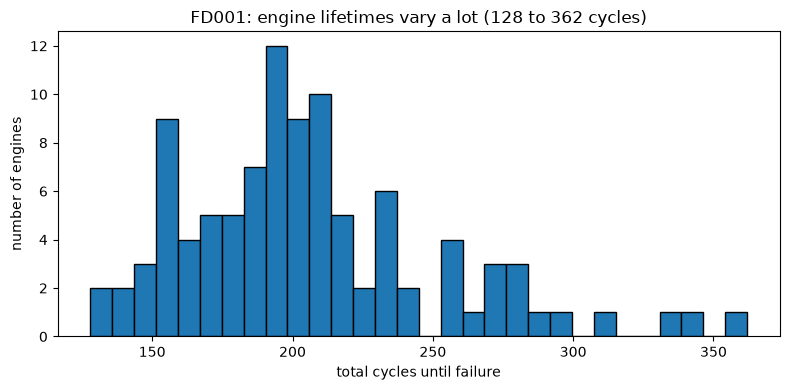

In [2]:
max_cycle = df.groupby("unit_id")["cycle"].max()
print(max_cycle.describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(max_cycle, bins=30, edgecolor="black")
ax.set_xlabel("total cycles until failure")
ax.set_ylabel("number of engines")
ax.set_title("FD001: engine lifetimes vary a lot (128 to 362 cycles)")
plt.tight_layout()
plt.show()

Lifetimes are far from uniform - some engines fail after ~130 cycles, others last ~360. A fixed maintenance schedule would either waste life on the long-lived engines or miss the short-lived ones. That variance is exactly why RUL prediction is useful here.

## 2. RUL target preview

RUL at any row = (unit's max cycle) - (current cycle). This is only a preview - the real labeling (with clipping) happens in Phase 1.

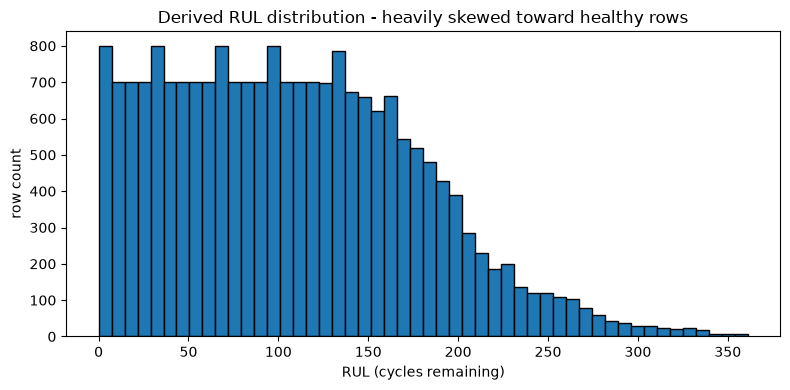

In [3]:
rul = df["unit_id"].map(max_cycle) - df["cycle"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rul, bins=50, edgecolor="black")
ax.set_xlabel("RUL (cycles remaining)")
ax.set_ylabel("row count")
ax.set_title("Derived RUL distribution - heavily skewed toward healthy rows")
plt.tight_layout()
plt.show()

Most rows are "healthy, failure far away" and only a small tail is near failure. If a model trains on raw RUL it spends most of its effort predicting large values that don't matter operationally - this is the reason the plan clips RUL at a max threshold (~125) in Phase 1.

## 3. Sensor behaviour for one engine - trend vs flat

All 21 sensors for a single engine (unit 1), from first cycle to failure. What I'm looking for: which sensors drift as the engine wears out, and which stay flat.

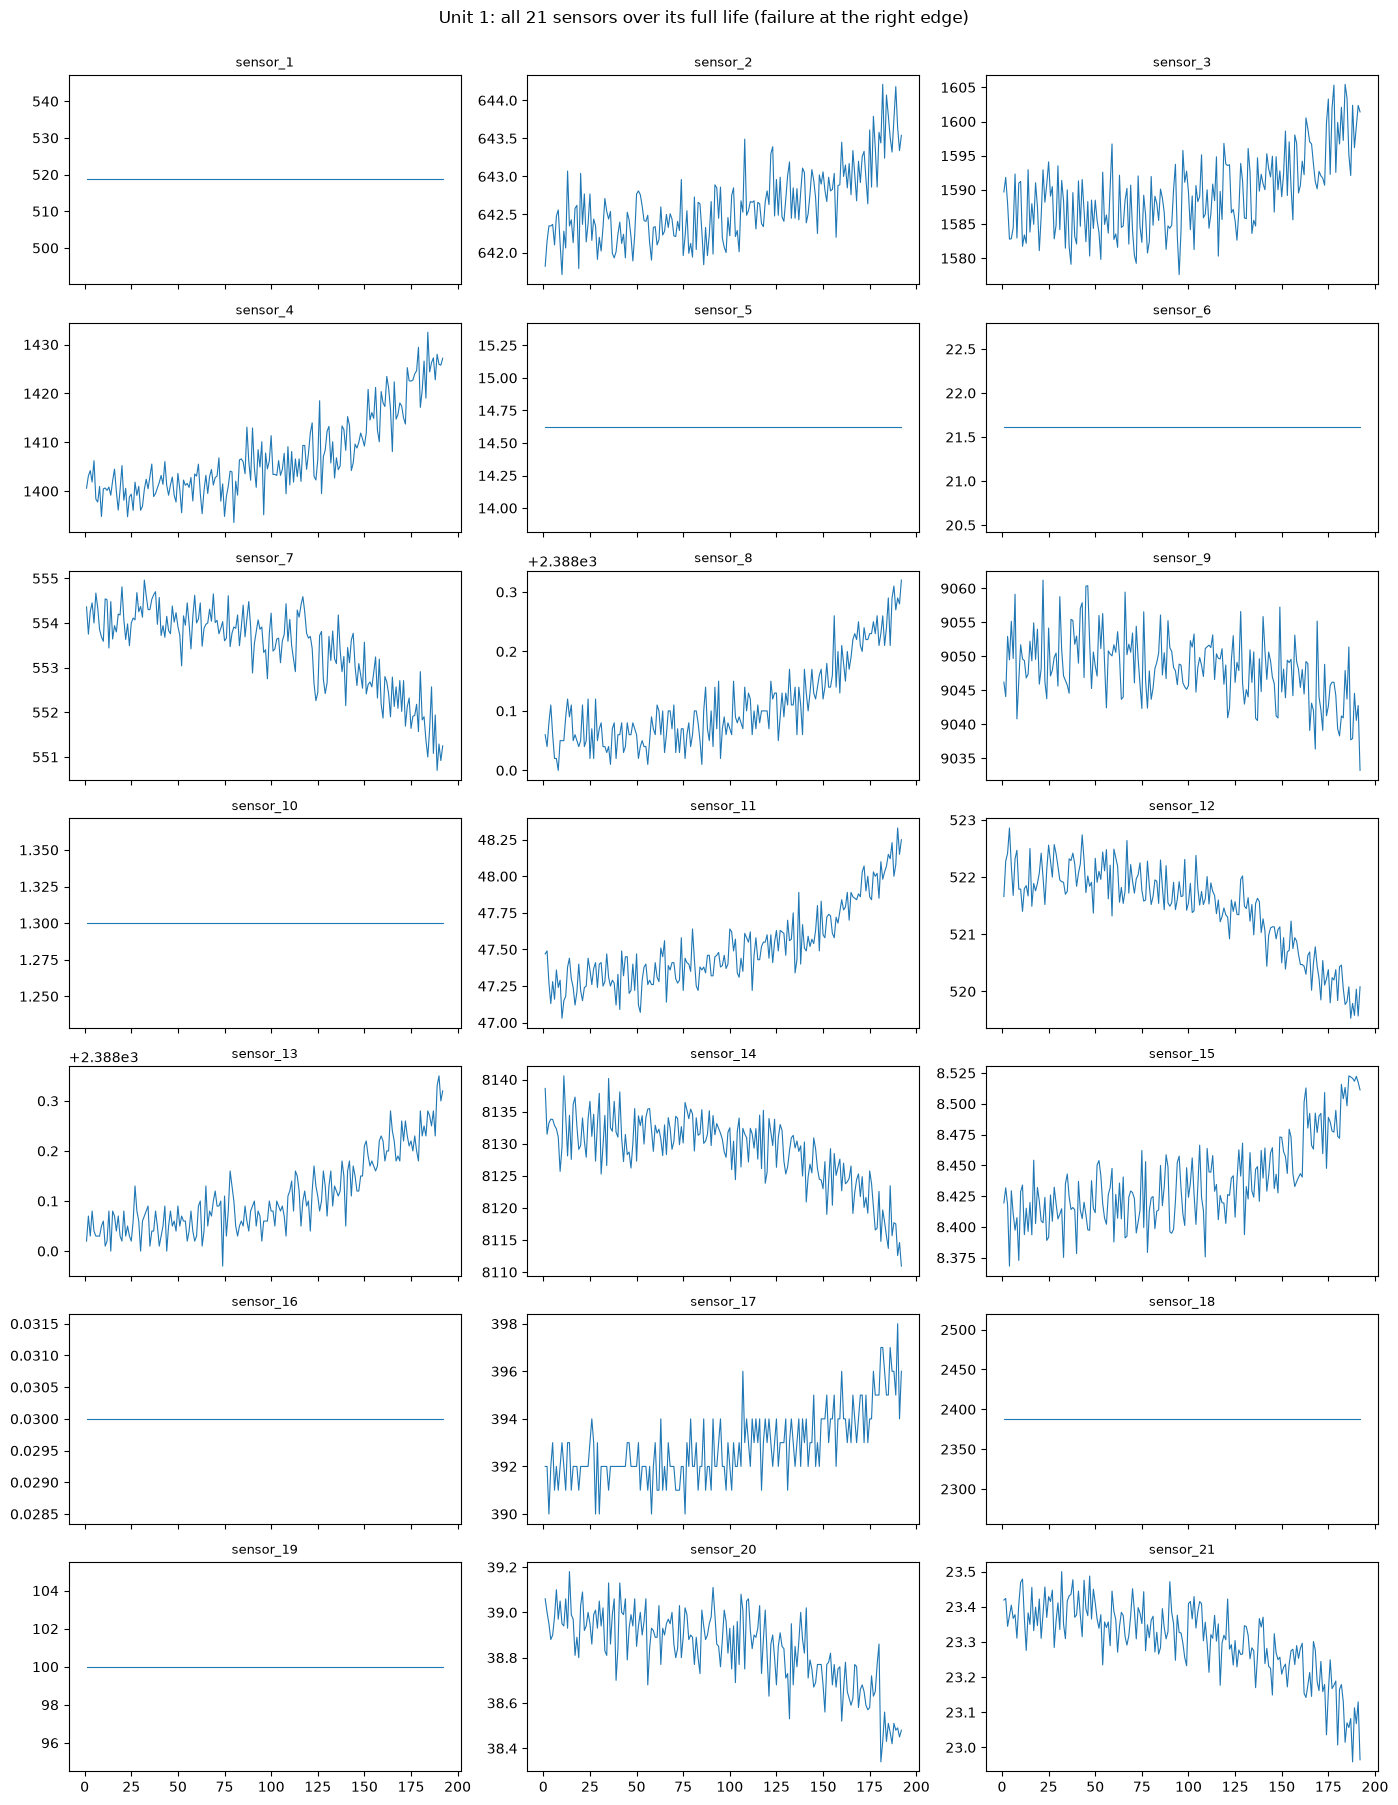

In [4]:
unit = df[df["unit_id"] == 1]

fig, axes = plt.subplots(7, 3, figsize=(14, 18), sharex=True)
for i, ax in enumerate(axes.flat, start=1):
    ax.plot(unit["cycle"], unit[f"sensor_{i}"], linewidth=0.8)
    ax.set_title(f"sensor_{i}", fontsize=9)
fig.suptitle("Unit 1: all 21 sensors over its full life (failure at the right edge)", y=1.0)
plt.tight_layout()
plt.show()

## 4. Which sensors actually move? (variance check)

Eyeballing plots is not enough - a quick standard-deviation check across the whole training set confirms which sensors are constant.

In [5]:
sensor_std = df[[f"sensor_{i}" for i in range(1, 22)]].std().sort_values()
print(sensor_std)

print("\nop settings std (FD001 = single operating condition):")
print(df[[f"op_setting_{i}" for i in range(1, 4)]].std())

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

op settings std (FD001 = single operating condition):
op_setting_1    0.002187
op_setting_2    0.000293
op_setting_3    0.000000
dtype: float64


## Observations (what this means for Phase 1 features)

- **Flat / dead sensors in FD001:** `sensor_1, 5, 6, 10, 16, 18, 19` - std is 0 (or ~0). They carry no information here and can be dropped (or left in - LightGBM will ignore them, but dropping keeps plots and SHAP output cleaner).
- **Clear degradation trends:** `sensor_11, 12, 4, 7, 15, 20, 21` drift steadily over an engine's life (visible in the unit-1 grid, e.g. sensor_11 rises, sensor_12 falls). `sensor_2, 3, 8, 13, 17` also trend but with more noise. These are the raw material for rolling/lag/slope features in Phase 1.
- **Sensors are noisy:** even the trending ones wiggle cycle-to-cycle, so a single reading says little - rolling statistics (mean/std over a window) should expose the trend much better than raw values.
- **Operational settings are nearly constant** in FD001 (single operating condition), so they will not help the model for this subset. FD002/FD004 have 6 conditions - there they will matter.
- **Lifetimes vary ~3x** (128-362 cycles), confirming that per-unit degradation state, not calendar/cycle age alone, must drive predictions.

Next: Phase 1 - RUL labeling with clipping, rolling/lag/slope features, and the unit-wise split.